In [1]:
"""
Assam Flood Detection Example

Session 1
---------

1. Read Sentinel-1 images
2. Inspect metadata
3. Apply Refined Lee
4. Inspect filtered images
"""
import os
import sys
################
module_path = os.path.abspath(os.path.expanduser("~/notebooks/geospatial/"))
# print(f"Module path is {module_path}")
# print(f"Sys path is {sys.path}")
if module_path not in sys.path:
    print("$$$$$$$$")
    sys.path.append(module_path)
#####################
from pathlib import Path

from sar.sar_geometry import align_to_reference

import numpy as np

from sar.sar_radiometry import (db_to_linear,linear_to_db)

from sar.threshold import *

from sar.filters.refined_lee_geosar import (refined_lee,)

from sar.sar_io import load_sar

from sar.sar_change import *

import matplotlib.pyplot as plt


$$$$$$$$


In [2]:
DATA_DIR = Path("/home/ubuntu/notebooks/geospatial")

PRE_IMAGE = (
    DATA_DIR /
    "sample_image_preflood1.tif"
)

POST_IMAGE = (
    DATA_DIR /
    "sample_image_postflood1.tif"
)

In [3]:
def summarize_image(
    image,
    name,
):
    """
    Print a concise summary of a SAR image.
    """

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Shape        : {image.shape}")

    print(f"CRS          : {image.crs}")

    print(f"Value Scale  : {image.value_scale}")

    print(
        f"Resolution   : {image.metadata.spatial.resolution}")

    valid = image.data[image.mask]
    
    valid = valid[np.isfinite(valid)]

    print(
        f"Valid Pixels : {valid.size}"
    )

    print(
        f"Minimum      : {valid.min():.6f}"
    )

    print(
        f"Maximum      : {valid.max():.6f}"
    )

    print(
        f"Mean         : {valid.mean():.6f}"
    )

    print(
        f"Std Dev      : {valid.std():.6f}"
    )

    print()


def show_change_image(
    image,
    title,
    cmap,
    percentile=2,
):
    """
    Display a change image using robust
    percentile stretching.
    """

    valid = image.data[image.mask]

    vmin = np.percentile(
        valid,
        percentile,
    )

    vmax = np.percentile(
        valid,
        100 - percentile,
    )

    plt.figure(figsize=(10, 8))

    plt.imshow(
        image.data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar()

    plt.title(title)

    plt.tight_layout()

    plt.show()


def print_statistics(
    image,
    name,
):
    valid = image.data[image.mask]

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Minimum : {valid.min():.4f}")
    print(f"Maximum : {valid.max():.4f}")
    print(f"Mean    : {valid.mean():.4f}")
    print(f"Median  : {np.median(valid):.4f}")
    print(f"Std Dev : {valid.std():.4f}")


def show_histogram(
    image,
    title,
    bins=200,
):
    valid = image.data[image.mask]

    plt.figure(figsize=(8, 5))

    low = np.percentile(valid, 1)
    high = np.percentile(valid, 99)

    plt.hist(
    valid[
        (valid >= low)
        &
        (valid <= high)
    ],
    bins=200,
)

    # plt.hist(
    #     valid,
    #     bins=bins,
    # )

    plt.title(title)

    plt.xlabel("Value")

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

In [4]:
print("=" * 70)
print("READING IMAGES")
print("=" * 70)

pre = load_sar(
    PRE_IMAGE,
)

post = load_sar(
    POST_IMAGE,
)

if pre.value_scale.lower() == "db":
    print("Converting pre image to linear...")
    pre = db_to_linear(pre)

if post.value_scale.lower() == "db":
    print("Converting post image to linear...")
    post = db_to_linear(post)

print("Done.\n")

summarize_image(
    pre,
    "PRE-FLOOD IMAGE",
)

summarize_image(
    post,
    "POST-FLOOD IMAGE",
)

READING IMAGES
Converting pre image to linear...
Converting post image to linear...
Done.

PRE-FLOOD IMAGE
Shape        : (5608, 5071)
CRS          : EPSG:32646
Value Scale  : Linear
Resolution   : (10.0, 10.0)
Valid Pixels : 15380333
Minimum      : 0.000000
Maximum      : 128.954880
Mean         : 0.125486
Std Dev      : 0.246627

POST-FLOOD IMAGE
Shape        : (5607, 5070)
CRS          : EPSG:32646
Value Scale  : Linear
Resolution   : (10.0, 10.0)
Valid Pixels : 15377210
Minimum      : 0.000000
Maximum      : 824.409119
Mean         : 0.127254
Std Dev      : 0.801200



In [8]:
pre.metadata.processing

ProcessingMetadata(processing_level='GRD', product_type='GTiff', value_scale='Linear', software='', calibration='', terrain_corrected=False, speckle_filtered=False)

In [7]:
print("=" * 70)
print("VALIDATION")
print("=" * 70)


if pre.shape != post.shape:

    print(
        "Aligning post image..."
    )

    post = align_to_reference(
        reference=pre,
        moving=post,
    )

assert (
    pre.crs
    ==
    post.crs
)

assert (
    pre.value_scale
    ==
    post.value_scale
)

print("✓ Images are compatible.\n")

print("=" * 70)
print("PRE IMAGE BEFORE REFINED LEE")
print("=" * 70)

print(
    "NaNs:",
    np.isnan(pre.data).sum(),
)

print(
    "Mask True:",
    pre.mask.sum(),
)

print(
    "NaNs inside valid:",
    np.isnan(
        pre.data[
            pre.mask
        ]
    ).sum(),
)

VALIDATION
Aligning post image...
✓ Images are compatible.

PRE IMAGE BEFORE REFINED LEE
NaNs: 13057835
Mask True: 15380333
NaNs inside valid: 0


In [ ]:
pre.

In [9]:
print("=" * 70)
print("APPLYING REFINED LEE")
print("=" * 70)

pre_filtered = refined_lee(
    pre,
)
post_filtered = refined_lee(
    post,
)

print("Done.\n")


summarize_image(
    pre_filtered,
    "PRE-FLOOD (FILTERED)",
)

summarize_image(
    post_filtered,
    "POST-FLOOD (FILTERED)",
)

print("=" * 70)
print("SESSION 1 COMPLETE")
print("=" * 70)

print(
    "Images successfully read and filtered."
)

APPLYING REFINED LEE
NaNs in windows: 639827139
NaNs in first patch: 49
Mean == 0: 0
Mean < 1e-12: 0
Variance NaN: 117357522
Noise NaNs inside valid: 2
Directional mean NaNs inside valid: 0
Directional variance NaNs inside valid: 0
Signal variance NaNs inside valid: 2
Weight NaNs inside valid: 2
Filtered NaNs: 13057837
NaNs in windows: 640135120
NaNs in first patch: 42
Mean == 0: 158366
Mean < 1e-12: 158366
Variance NaN: 117307699
Noise NaNs inside valid: 10429
Directional mean NaNs inside valid: 0
Directional variance NaNs inside valid: 0
Signal variance NaNs inside valid: 10429
Weight NaNs inside valid: 10429
Filtered NaNs: 13069932
Done.

PRE-FLOOD (FILTERED)
Shape        : (5608, 5071)
CRS          : EPSG:32646
Value Scale  : Linear
Resolution   : (10.0, 10.0)
Valid Pixels : 15379918
Minimum      : 0.000008
Maximum      : 50.081970
Mean         : 0.129299
Std Dev      : 0.165956

POST-FLOOD (FILTERED)
Shape        : (5608, 5071)
CRS          : EPSG:32646
Value Scale  : Linear
Resol

In [10]:
print("=" * 70)
print("CHANGE DETECTION")
print("=" * 70)

difference = difference_change(
    pre_filtered,
    post_filtered,
)

ratio = ratio_change(
    pre_filtered,
    post_filtered,
)

log_ratio = log_ratio_change(
    pre_filtered,
    post_filtered,
)

print("Done.\n")

CHANGE DETECTION
Done.



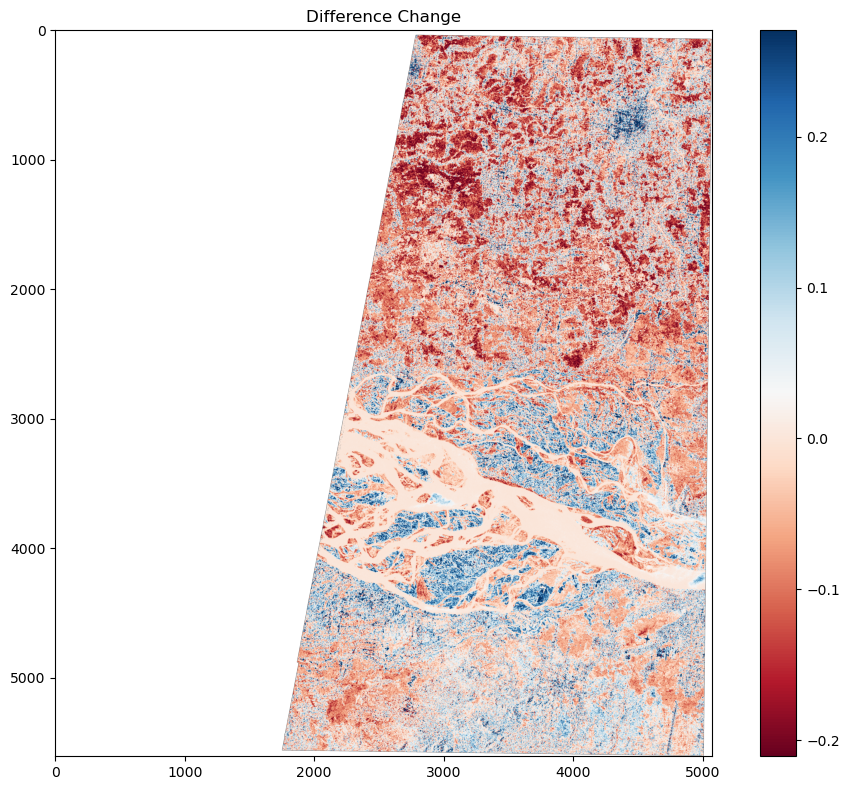

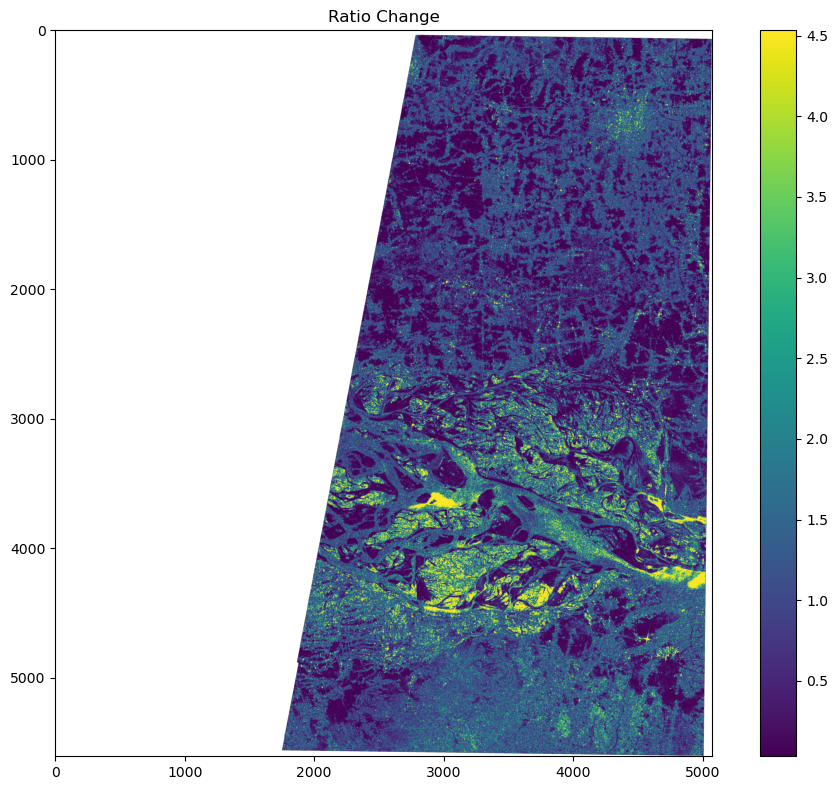

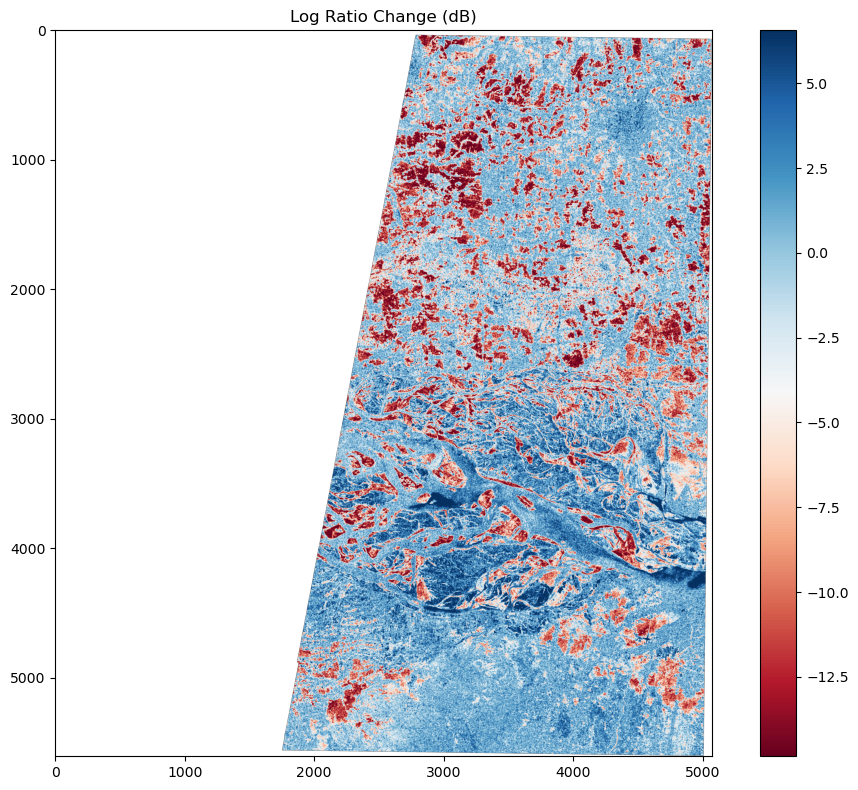

In [11]:
show_change_image(
    difference,
    "Difference Change",
    cmap="RdBu",
)

show_change_image(
    ratio,
    "Ratio Change",
    cmap="viridis",
)

show_change_image(
    log_ratio,
    "Log Ratio Change (dB)",
    cmap="RdBu",
)

In [12]:
print_statistics(
    difference,
    "Difference",
)

print_statistics(
    ratio,
    "Ratio",
)

print_statistics(
    log_ratio,
    "Log Ratio",
)

Difference
Minimum : -25.6107
Maximum : 412.1937
Mean    : 0.0017
Median  : -0.0092
Std Dev : 0.4908
Ratio
Minimum : 0.0013
Maximum : 6143.0704
Mean    : 1.1623
Median  : 0.8686
Std Dev : 6.4410
Log Ratio
Minimum : -28.8333
Maximum : 37.8839
Mean    : -1.9979
Median  : -0.6118
Std Dev : 5.4266


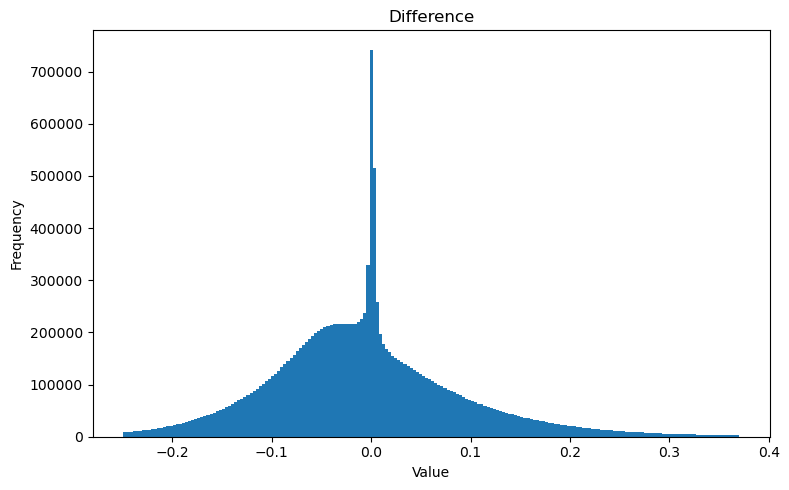

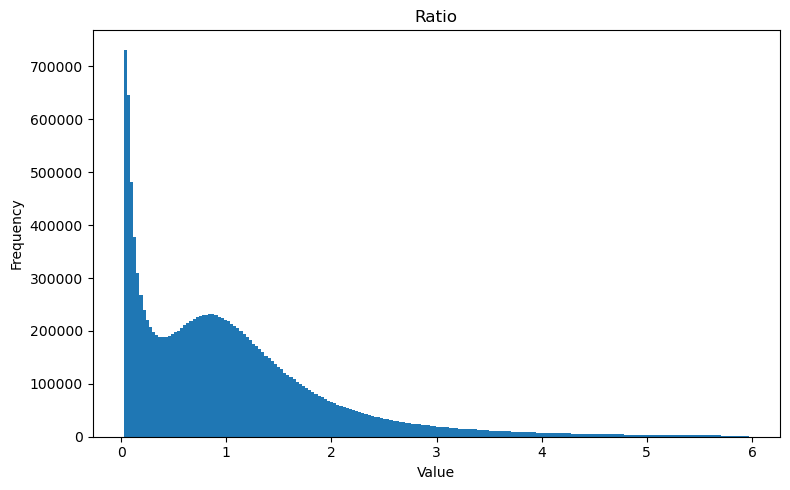

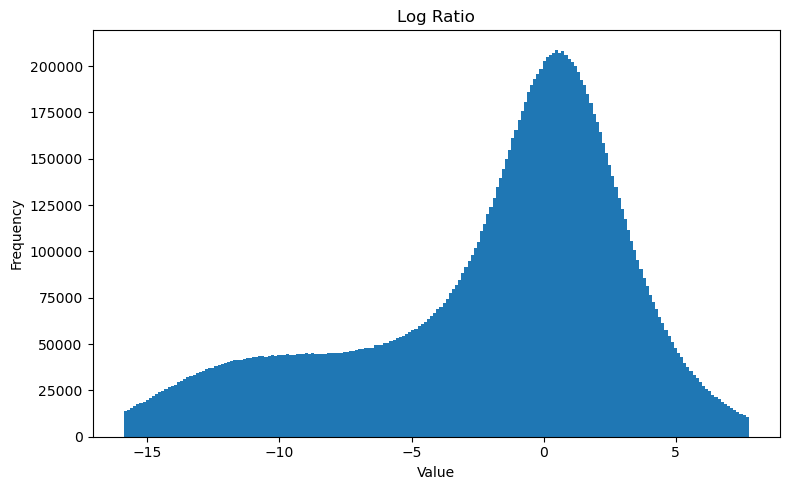

In [13]:
show_histogram(
    difference,
    "Difference",
)

show_histogram(
    ratio,
    "Ratio",
)

show_histogram(
    log_ratio,
    "Log Ratio",
)

In [ ]:
thresholds = [-1,-2,-3,-4,-5,-6,]

for t in thresholds:

    binary = threshold_less_than(
        log_ratio,
        t,
    )

    show_binary(
        binary,
        f"Threshold = {t} dB",
    )

In [15]:
for t in thresholds:

    binary = threshold_less_than(
        log_ratio,
        t,
    )

    flooded = binary.data.sum()

    percentage = (
        100
        * flooded
        / log_ratio.mask.sum()
    )

    print(
        f"{t:5.1f} dB : "
        f"{flooded:10d} pixels "
        f"({percentage:.2f}%)"
    )

 -1.0 dB :    7105416 pixels (46.24%)
 -2.0 dB :    5872245 pixels (38.21%)
 -3.0 dB :    4978525 pixels (32.40%)
 -4.0 dB :    4318136 pixels (28.10%)
 -5.0 dB :    3792531 pixels (24.68%)
 -6.0 dB :    3340534 pixels (21.74%)


In [16]:
areas = []

for t in thresholds:

    binary = threshold_less_than(
        log_ratio,
        t,
    )

    areas.append(
        binary.data.sum()
    )

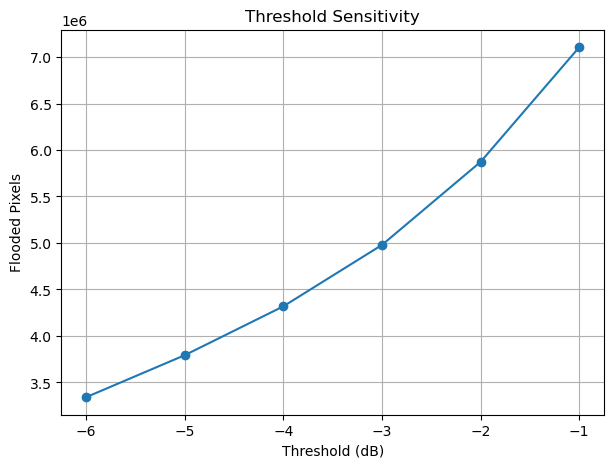

In [17]:
plt.figure(figsize=(7,5))

plt.plot(
    thresholds,
    areas,
    marker="o",
)

plt.grid(True)

plt.xlabel("Threshold (dB)")

plt.ylabel("Flooded Pixels")

plt.title("Threshold Sensitivity")

plt.show()